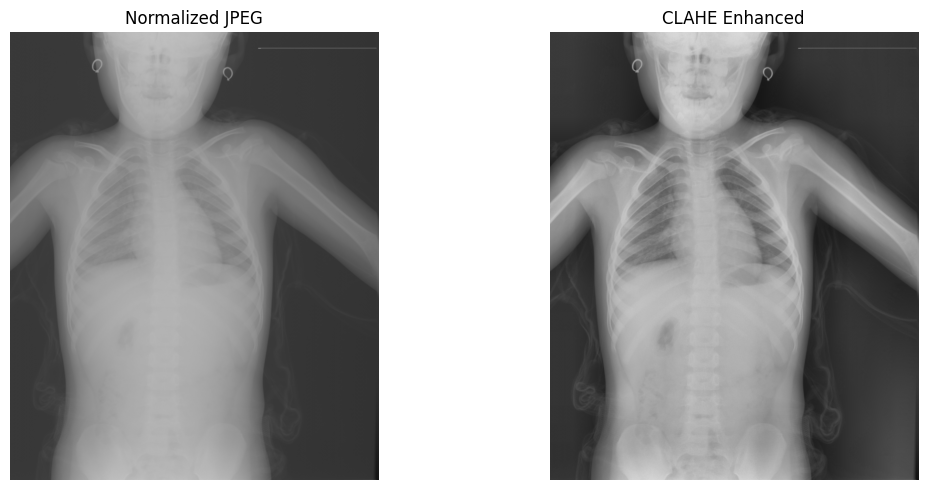

In [2]:
import cv2
import matplotlib.pyplot as plt

# Read the normalized JPEG
image = cv2.imread(r"D:\ai-based-medical-imaging\Chest X-rays Jpeg\1.2.840.113564.54.2026020613015627.948.jpg", cv2.IMREAD_GRAYSCALE)

# Create CLAHE object
clahe = cv2.createCLAHE(
    clipLimit=2.0,
    tileGridSize=(8, 8)
)

# Apply CLAHE
enhanced = clahe.apply(image)

# Save the enhanced image
cv2.imwrite("normalized_clahe.jpg", enhanced)

# Display
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Normalized JPEG")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(enhanced, cmap="gray")
plt.title("CLAHE Enhanced")
plt.axis("off")

plt.tight_layout()
plt.show()

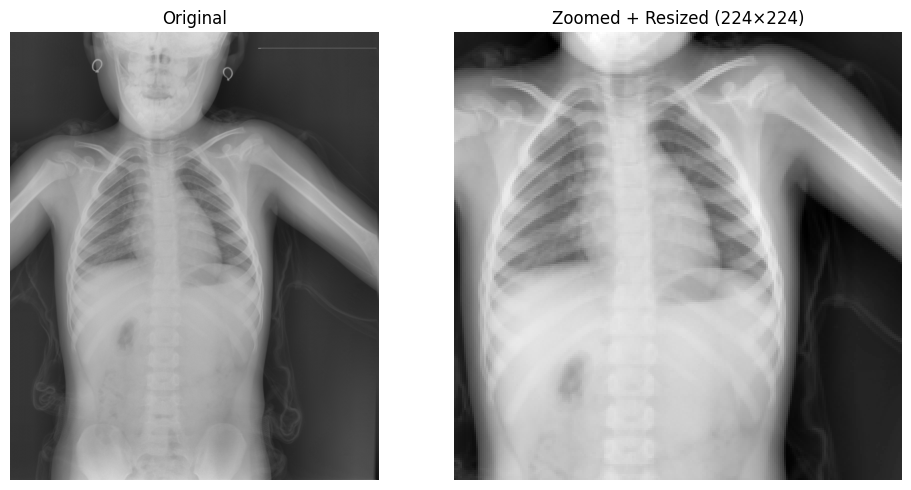

In [3]:
import cv2
import matplotlib.pyplot as plt
import torch
from torchvision import transforms

# Read grayscale image
image = cv2.imread("normalized_clahe.jpg", cv2.IMREAD_GRAYSCALE)

# Convert to tensor (shape: 1 x H x W)
image = torch.from_numpy(image).float() / 255.0
image = image.unsqueeze(0)

# Define preprocessing pipeline
transform = transforms.Compose([
    transforms.CenterCrop((1800, 1800)),   # Adjust crop size based on your image
    transforms.Resize((224, 224), antialias=True)
])

zoomed = transform(image)

# Convert back to numpy for visualization
zoomed_np = zoomed.squeeze().numpy()

# Display
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image.squeeze().numpy(), cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(zoomed_np, cmap="gray")
plt.title("Zoomed + Resized (224×224)")
plt.axis("off")

plt.tight_layout()
plt.show()

In [8]:
image.squeeze().shape , zoomed.squeeze().shape

(torch.Size([2800, 2304]), torch.Size([224, 224]))

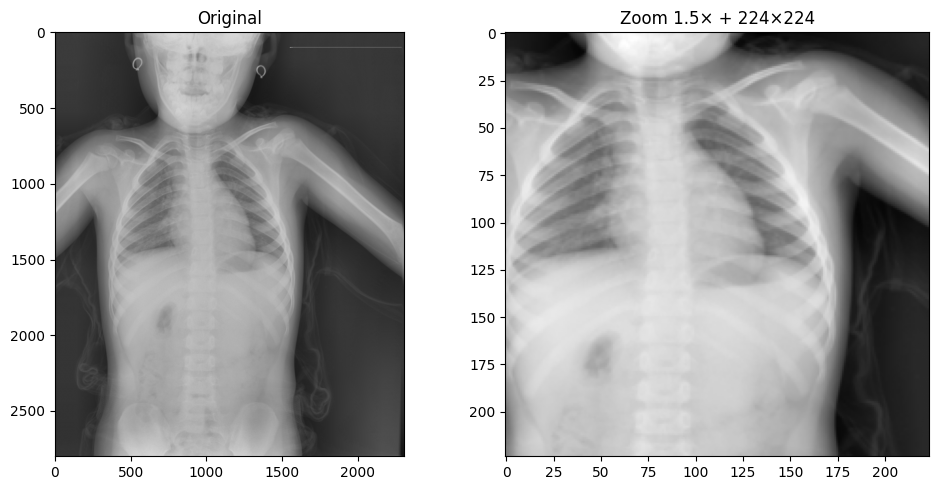

In [10]:
import cv2
import matplotlib.pyplot as plt
import torch
from torchvision import transforms

image = cv2.imread("normalized_clahe.jpg", cv2.IMREAD_GRAYSCALE)

image = torch.from_numpy(image).float() / 255.0
image = image.unsqueeze(0)

H, W = image.shape[1:]

zoom_factor = 1.5

crop_h = int(H / zoom_factor)
crop_w = int(W / zoom_factor)

transform = transforms.Compose([
    transforms.CenterCrop((crop_h, crop_w)),
    transforms.Resize((224, 224), antialias=True)
])

zoomed = transform(image)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(image.squeeze().numpy(), cmap="gray")
plt.title("Original")

plt.subplot(1,2,2)
plt.imshow(zoomed.squeeze().numpy(), cmap="gray")
plt.title(f"Zoom {zoom_factor:.1f}× + 224×224")

plt.tight_layout()
plt.show()